In [3]:
# Import pandas library for reading and manipulating datasets
import pandas as pd

In [4]:
# Import numpy library for mathematical operations

df = pd.read_csv("C:/Users/vinee/Downloads/Housing dataset.csv")

In [5]:
# Display the dataset
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Distance_City,School_Rating,Crime_Index,Hospital_Distance,Mall_Distance,Public_Transport,Garden,Pool,Garage,Income_Area,Population_Density,Air_Quality,Property_Tax,Price
0,1412,1,3,2,1,8,22.23,9,1.78,8.73,1.08,4,0,0,0,113850,18356,74.54,8359,1813543
1,553,2,4,3,2,9,6.85,6,1.92,7.91,7.50,6,1,0,1,90284,4590,146.51,7201,2161450
2,2901,6,5,3,4,12,21.28,1,6.95,15.57,19.71,4,0,1,1,79429,12454,41.15,6820,3661515
3,2687,6,1,2,4,46,7.72,8,4.42,19.80,12.98,9,0,1,0,50021,1551,124.66,7572,2681257
4,1042,2,5,3,1,41,15.23,8,2.29,3.22,15.03,9,1,1,1,67447,7686,149.65,3266,2630069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,998,6,2,1,1,39,22.68,5,2.04,11.93,13.90,8,1,0,0,42093,18341,107.36,9705,1892005
9996,1791,6,3,3,2,13,17.88,8,1.03,19.74,17.43,8,0,0,1,120864,17377,109.70,7174,3420712
9997,2699,5,1,2,2,12,10.33,6,7.26,8.07,17.23,4,1,0,1,71455,8043,135.96,7070,2569860
9998,2472,1,4,4,2,42,22.67,10,4.22,9.12,7.94,5,0,1,1,77960,18504,28.26,9032,2186662


In [6]:
# Display the first 5 rows of the dataset
df.head

<bound method NDFrame.head of       Area  Bedrooms  Bathrooms  Stories  Parking  Age  Distance_City  \
0     1412         1          3        2        1    8          22.23   
1      553         2          4        3        2    9           6.85   
2     2901         6          5        3        4   12          21.28   
3     2687         6          1        2        4   46           7.72   
4     1042         2          5        3        1   41          15.23   
...    ...       ...        ...      ...      ...  ...            ...   
9995   998         6          2        1        1   39          22.68   
9996  1791         6          3        3        2   13          17.88   
9997  2699         5          1        2        2   12          10.33   
9998  2472         1          4        4        2   42          22.67   
9999  3605         4          5        1        1   47          28.63   

      School_Rating  Crime_Index  Hospital_Distance  Mall_Distance  \
0                 9    

In [7]:
#Display the columns
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age',
       'Distance_City', 'School_Rating', 'Crime_Index', 'Hospital_Distance',
       'Mall_Distance', 'Public_Transport', 'Garden', 'Pool', 'Garage',
       'Income_Area', 'Population_Density', 'Air_Quality', 'Property_Tax',
       'Price'],
      dtype='object')

In [8]:
# X contains all input features except the Price column
X = df.drop("Price", axis=1)
# y contains the output variable (House Price)
y = df["Price"]

In [9]:
print(X.shape)
print(y.shape)

(10000, 19)
(10000,)


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# Split the dataset into 80% training data and 20% testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
# Train the model using the training dataset
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Predict prices for the test dataset
predictions = model.predict(X_test)

In [14]:
print(predictions)

[2021045.97573027 2263693.44065646 1655531.6137422  ... 3147051.7149225
 2801259.66200301 2522135.54530604]


In [15]:
from sklearn.metrics import r2_score

In [16]:
# Calculate R² Score
score = r2_score(y_test, predictions)

print(score)

0.9381931827948485


In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse=np.sqrt(mse)

In [18]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 149206.52379755836
MSE: 29918131414.92133
RMSE: 172968.5850520878


In [19]:
result = pd.DataFrame({
    "Actual_Price":y_test,
    "Predicted_Price":predictions
})

In [20]:
result.head

<bound method NDFrame.head of       Actual_Price  Predicted_Price
6252       1903349     2.021046e+06
4684       2410398     2.263693e+06
1731       1867968     1.655532e+06
4742       3151417     2.887188e+06
4521       3231907     3.336031e+06
...            ...              ...
6412       2355983     2.532370e+06
8285       3324884     3.177288e+06
7853       3372456     3.147052e+06
1095       2789003     2.801260e+06
6929       2704749     2.522136e+06

[2000 rows x 2 columns]>

In [21]:
result.head(10)

,Actual_Price,Predicted_Price
6252,1903349,2.021046e+06
4684,2410398,2.263693e+06
1731,1867968,1.655532e+06
4742,3151417,2.887188e+06
4521,3231907,3.336031e+06
6340,2272151,2.498327e+06
576,2413820,2.469292e+06
5202,1350017,1.436928e+06
6363,3743962,3.465216e+06
439,2650262,2.641810e+06


In [22]:
result = result.reset_index(drop=True)
result.head(10)

,Actual_Price,Predicted_Price
0,1903349,2.021046e+06
1,2410398,2.263693e+06
2,1867968,1.655532e+06
3,3151417,2.887188e+06
4,3231907,3.336031e+06
5,2272151,2.498327e+06
6,2413820,2.469292e+06
7,1350017,1.436928e+06
8,3743962,3.465216e+06
9,2650262,2.641810e+06


In [23]:
import matplotlib.pyplot as plt

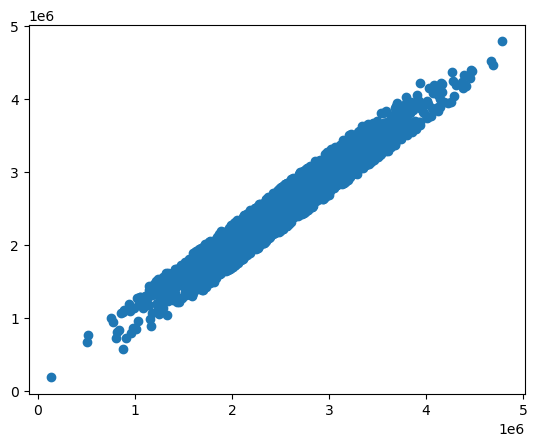

In [24]:
plt.scatter(y_test,predictions)

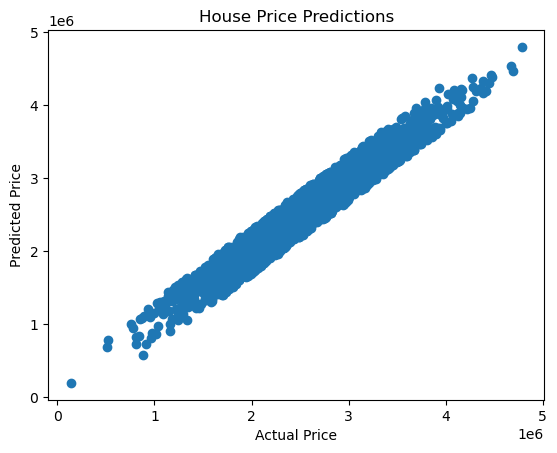

In [25]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Predictions")
plt.show()

In [26]:
type(model)

sklearn.linear_model._base.LinearRegression

In [27]:
X_train.shape

(8000, 19)

In [28]:
y_train.shape

(8000,)

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Training completed")

Training completed


In [30]:
print(model.coef_)

[ 1.80994369e+02  2.50195756e+05  1.79608605e+05  1.50638104e+05
  8.15468156e+04 -7.10028692e+03 -1.21320647e+04  3.98841091e+04
 -3.08968567e+04 -4.99361749e+03  3.89118767e+02 -7.04661481e+02
  9.75358404e+04  1.84998809e+05  1.24644142e+05  4.99531165e+00
  1.52146411e-01 -1.45911087e+03 -2.35739743e-01]


In [31]:
# Create a DataFrame containing feature names and their coefficients
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort coefficients from highest to lowest
importance = importance.sort_values(by="Coefficient", ascending=False)

# Display the result
print(importance)

               Feature    Coefficient
1             Bedrooms  250195.755725
13                Pool  184998.809440
2            Bathrooms  179608.605329
3              Stories  150638.104323
14              Garage  124644.141683
12              Garden   97535.840447
4              Parking   81546.815606
7        School_Rating   39884.109118
10       Mall_Distance     389.118767
0                 Area     180.994369
15         Income_Area       4.995312
16  Population_Density       0.152146
18        Property_Tax      -0.235740
11    Public_Transport    -704.661481
17         Air_Quality   -1459.110869
9    Hospital_Distance   -4993.617492
5                  Age   -7100.286919
6        Distance_City  -12132.064744
8          Crime_Index  -30896.856660


In [32]:
# Create a new house with sample values
new_house = pd.DataFrame({
    "Area": [1700],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Stories": [2],
    "Parking": [2],
    "Age": [5],
    "Distance_City": [7],
    "School_Rating": [8],
    "Crime_Index": [15],
    "Hospital_Distance": [3],
    "Mall_Distance": [4],
    "Public_Transport": [1],
    "Garden": [1],
    "Pool": [0],
    "Garage": [1],
    "Income_Area": [75000],
    "Population_Density": [5000],
    "Air_Quality": [40],
    "Property_Tax": [90000]
})

In [33]:
# Predict the price of the new house
predicted_price = model.predict(new_house)

print("Predicted House Price: ₹", round(predicted_price[0], 2))

Predicted House Price: ₹ 2541925.54


In [34]:
import joblib

In [35]:
# Save the trained model
joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [36]:
sample = df.head(100)
sample.to_csv("Housing_sample.csv", index=False)